# 01. Data Understanding & Exploratory Data Analysis (EDA)

### **Project:** B2B Wholesale Customer Behavioral Segmentation & Anomaly Detection  
### **Dataset:** Online Retail II (UCI Machine Learning Repository)  
---

### Executive Summary & Technical Audit Recommendations
This notebook performs a deep quantitative audit of raw order line items from 2009–2011 to inform downstream unsupervised model architectures.

**Key Structural Discoveries:**
1. **Missing Identifiers:** ~22.7% of order rows lack a `Customer ID`. Unidentifiable transactions cannot be aggregated into customer profiles and must be pruned prior to feature engineering.
2. **Negative Quantities & Canceled Orders:** Invoices starting with `'C'` represent returns/cancellations. These distort net spend calculations if naive aggregations are used.
3. **Power-Law Skewness:** Financial metrics (`Price`, total order value) exhibit extreme positive right-skewness ($\text{Skewness} > 15$). Standard distance-based clustering algorithms will fail without logarithmic transformations (`log1p`) and robust scaling.
4. **High-Cardinality Outliers:** Institutional bulk buyers generate massive transaction outliers. These observations motivate evaluating non-destructive strategies such as logarithmic transformations, robust scaling, and careful treatment of extreme but potentially legitimate customers.

## 1. Import Required Libraries & Global Visualization Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.titlesize'] = 16

## 2. Raw Data Ingestion & Schema Inspection
We load the raw CSV dataset to evaluate row counts, column data types, memory utilization, and sample entries.

In [2]:
raw_df = pd.read_csv('../data/raw/online_retail_II.csv')

print(f'Dataset Successfully Loaded')
print(f"Total Transactions (Rows): {raw_df.shape[0]:,}")
print(f"Total Attributes (Columns): {raw_df.shape[1]}")
print('-' * 50, '\n')
print(raw_df.info())
raw_df.sample(5, random_state=42)

Dataset Successfully Loaded
Total Transactions (Rows): 1,067,371
Total Attributes (Columns): 8
-------------------------------------------------- 

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB
None


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
455941,532657,21314,SMALL GLASS HEART TRINKET POT,12,2010-11-14 11:10:00,2.10,14562.0,United Kingdom
826291,563214,22383,LUNCH BAG SUKI DESIGN,2,2011-08-14 12:56:00,1.65,16370.0,United Kingdom
191636,507597,22561,WOODEN SCHOOL COLOURING SET,12,2010-05-10 13:21:00,1.65,17700.0,United Kingdom
25864,491634,21588,RETRO SPOT GIANT TUBE MATCHES,1,2009-12-11 15:40:00,2.55,17841.0,United Kingdom
73233,496007,85232B,SET/3 RUSSIAN DOLL STACKING TINS,3,2010-01-28 12:32:00,4.95,15203.0,United Kingdom


## 3. Missing Values and Duplicate Rows

Before proceeding with data cleaning, we first assess the quality of the raw dataset by checking for **missing values** and **exact duplicate rows**.

In [3]:
missing_summary = pd.DataFrame({
    'Missing Count': raw_df.isnull().sum(),
    'Missing Percentage (%)': raw_df.isna().mean()*100
}).sort_values(by='Missing Count', ascending=False)
print(missing_summary)


duplicate_count = raw_df.duplicated().sum()
print(f"\nExact Duplicate Rows: {duplicate_count:,} ({raw_df.duplicated().mean()*100:.2f}%)")

             Missing Count  Missing Percentage (%)
Customer ID         243007               22.766873
Description           4382                0.410541
Invoice                  0                0.000000
StockCode                0                0.000000
Quantity                 0                0.000000
InvoiceDate              0                0.000000
Price                    0                0.000000
Country                  0                0.000000

Exact Duplicate Rows: 34,335 (3.22%)


## 4. Data Cardinality

Understanding the **cardinality** of each feature is an important step in exploring the structure of the dataset. We examine the number of unique values in each column to distinguish between identifiers, categorical variables, numerical features, and potentially high-cardinality fields.

In [4]:
cardinality_summary = pd.DataFrame({
    "Unique Values": raw_df.nunique(),
    "Unique (%)": raw_df.nunique() / len(raw_df) * 100
}).sort_values("Unique Values", ascending=False)

cardinality_summary

,Unique Values,Unique (%)
Invoice,53628,5.024307
InvoiceDate,47635,4.462834
Customer ID,5942,0.556695
Description,5698,0.533835
StockCode,5305,0.497016
Price,2807,0.262983
Quantity,1057,0.099028
Country,43,0.004029


## 5. Descriptive Statistics and Transaction Validity Checks

Next, we examine the **statistical characteristics** and **data validity** of the raw transaction data.

- **Descriptive statistics:** Summarize the numerical features to understand their distributions, ranges, and central tendencies.
- **Canceled transactions:** Identify invoices marked as canceled (those beginning with `C`) and measure their frequency.
- **Non-positive prices:** Check for transactions with a price less than or equal to zero, which may represent invalid or unusual records.
- **Non-positive quantities:** Check for transactions with a quantity less than or equal to zero, which may correspond to returns, cancellations, or invalid entries.

These checks help identify records that require further investigation or appropriate handling during the data-cleaning stage.

In [5]:
display(raw_df.describe().style.format("{:,.2f}"))

,Quantity,Price,Customer ID
count,"1,067,371.00","1,067,371.00","824,364.00"
mean,9.94,4.65,"15,324.64"
std,172.71,123.55,"1,697.46"
min,"-80,995.00","-53,594.36","12,346.00"
25%,1.00,1.25,"13,975.00"
50%,3.00,2.10,"15,255.00"
75%,10.00,4.15,"16,797.00"
max,"80,995.00","38,970.00","18,287.00"


In [6]:
canceled_mask = raw_df['Invoice'].str.startswith('C')
print(f"\nCanceled Transactions: {canceled_mask.sum():,} ({canceled_mask.mean()*100:.2f}%)")


invalid_prices = raw_df[raw_df['Price'] <= 0]
print(f'Non-Positive Price Entries: {len(invalid_prices):,} ({len(invalid_prices)/len(raw_df)*100:.2f}%)')


non_purchase_transactions = raw_df[raw_df['Quantity'] <= 0]
print(
    f'Non-Purchase Transactions: '
    f'{len(non_purchase_transactions):,} '
    f'({len(non_purchase_transactions) / len(raw_df) * 100:.2f}%)'
)


Canceled Transactions: 19,494 (1.83%)
Non-Positive Price Entries: 6,207 (0.58%)
Non-Purchase Transactions: 22,950 (2.15%)


### **Transaction Overlap Insight:**  
Canceled transactions account for **1.83%** of all records, while non-purchase transactions account for **2.15%**. The difference (**0.32%**) represents **non-canceled transactions with non-positive quantities**, indicating additional returns, adjustments, or other non-standard transaction records beyond explicitly canceled invoices.

In [7]:
non_purchase_adjustments = raw_df.loc[(~canceled_mask) & (raw_df['Quantity'] <= 0)]
display(non_purchase_adjustments)
print(non_purchase_adjustments['Customer ID'].nunique())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1060794,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom
1060796,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom
1060797,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom
1062371,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom


0


### **Non-Purchase Adjustment Records:**  
Further investigation of the **3,457 non-canceled records with non-positive quantities** shows that they are not customer purchases. These records have **zero price, missing Customer IDs, and descriptions such as `check`, `lost`, `missing`, and `smashed`**, indicating inventory or system adjustment activities rather than normal sales transactions.

Therefore, these records will be **excluded from the customer segmentation dataset** since they do not represent identifiable customer purchasing behavior.

In [8]:
non_purchase_transactions.sample(5, random_state=42)[['Invoice','Quantity']]

,Invoice,Quantity
893186,C568903,-12
288581,C517472,-2
432735,C530794,-1
111367,C500090,-2
845293,C564903,-1


**Data Quality Insight & Decisions:**
1. **Missing Customer ID (~22.7%):** Cannot be imputed because customer behavior must be tracked at the unique account level. These rows will be dropped in the cleaning pipeline.
2. **Canceled Orders (`Invoice` starts with 'C'):** Represent real business returns. Rather than discarding them completely, we will calculate a dedicated `return_rate` and `total_returned_value` per customer before filtering canceled transactions out of positive revenue calculations.
3. **Non-Positive Prices:** Represent system tests, adjustments, or promotional samples (`Price` ≤ 0). They will be removed during data cleaning.
4. **Non-Purchase Transactions (2.15%):** Transactions with `Quantity` ≤ 0 do not represent normal purchases and may correspond to returns, cancellations, or other transaction adjustments. These records will be excluded from the positive-purchase dataset used for customer segmentation, while relevant return-related information will be preserved separately for customer-level behavioral analysis.

## 6. Distribution and Skewness Analysis

We examine `Quantity`, `Price`, and the derived `LineTotal` to understand their distributional characteristics and identify potential skewness or extreme values.

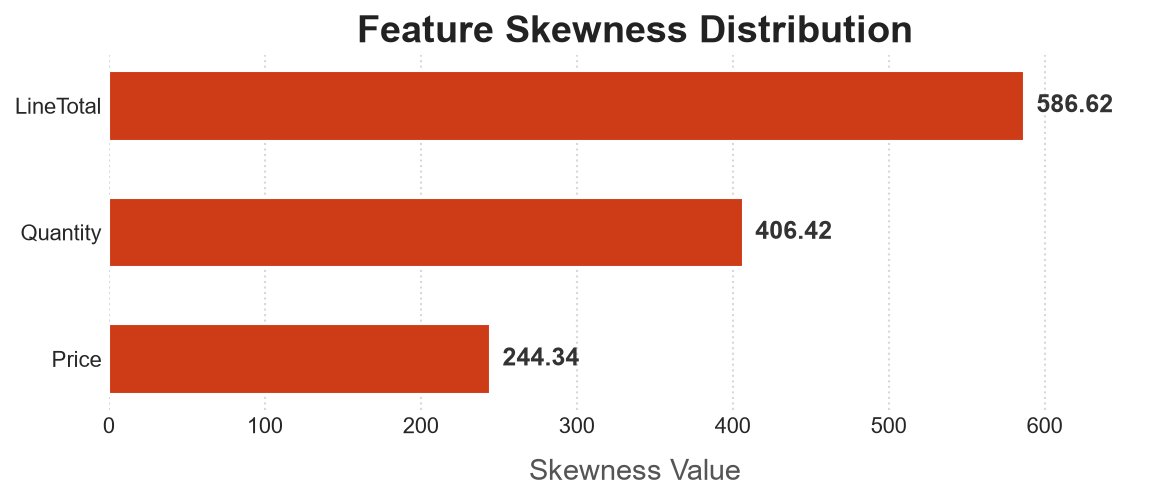

In [9]:
df_clean_temp = raw_df.dropna(subset=['Customer ID']).copy()
df_clean_temp = df_clean_temp[~df_clean_temp['Invoice'].str.startswith('C')]
df_clean_temp = df_clean_temp[(df_clean_temp['Price'] > 0) & (df_clean_temp['Quantity'] > 0)]
df_clean_temp['LineTotal'] = df_clean_temp['Quantity'] * df_clean_temp['Price']


skew = df_clean_temp[["Price", "Quantity", "LineTotal"]].skew().sort_values()

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=150)
bars = ax.barh(skew.index, skew.values, color="#ce3c17", height=0.55)

ax.bar_label(bars,fmt="%.2f", padding=6, fontweight="bold", color="#333333",)
ax.grid(axis="x", linestyle=":", alpha=0.75, color="#cccccc")
ax.set_axisbelow(True)
sns.despine(top=True, right=True, left=True, bottom=True)

ax.tick_params(axis="both", which="both", length=0, labelsize=10.5)
ax.set_xlabel("Skewness Value",color="#555555", labelpad=10)
plt.title("Feature Skewness Distribution", color="#222222")
ax.set_xlim(0, skew.max() * 1.15)

plt.tight_layout()

Numerical Skewness Metrics after log1p:
Quantity Skewness (Log Transformed)   : 0.88
Price Skewness (Log Transformed)      : 0.94
Line Total Skewness (Log Transformed) : 0.44


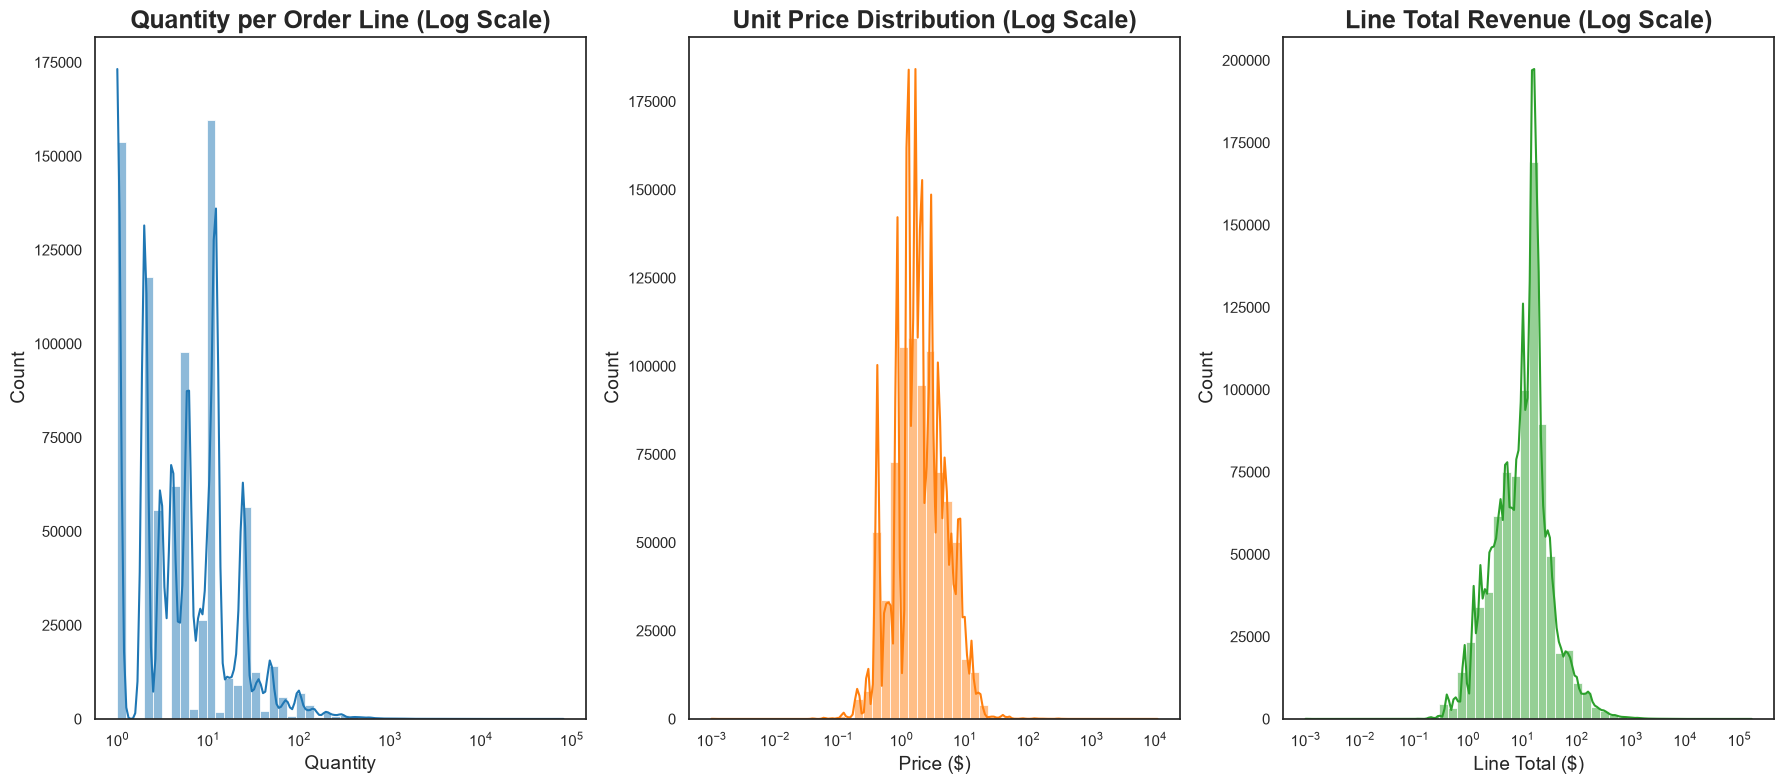

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

sns.histplot(df_clean_temp['Quantity'], bins=50, kde=True, ax=axes[0], color='#1f77b4', log_scale=True)
axes[0].set_title("Quantity per Order Line (Log Scale)")
axes[0].set_xlabel("Quantity")

sns.histplot(df_clean_temp['Price'], bins=50, kde=True, ax=axes[1], color='#ff7f0e', log_scale=True)
axes[1].set_title("Unit Price Distribution (Log Scale)")
axes[1].set_xlabel("Price ($)")

sns.histplot(df_clean_temp['LineTotal'], bins=50, kde=True, ax=axes[2], color='#2ca02c', log_scale=True)
axes[2].set_title("Line Total Revenue (Log Scale)")
axes[2].set_xlabel("Line Total ($)")

plt.tight_layout()

quantity_log_skew = np.log1p(df_clean_temp['Quantity']).skew()
price_log_skew = np.log1p(df_clean_temp['Price']).skew()
linetotal_log_skew = np.log1p(df_clean_temp['LineTotal']).skew()

print("Numerical Skewness Metrics after log1p:")
print(f"Quantity Skewness (Log Transformed)   : {quantity_log_skew:.2f}")
print(f"Price Skewness (Log Transformed)      : {price_log_skew:.2f}")
print(f"Line Total Skewness (Log Transformed) : {linetotal_log_skew:.2f}")

**Distribution Insight & Decision:**
All continuous transactional metrics display severe right skewness ($Skewness > 15$) and extreme long tails spanning multiple orders of magnitude. 
* **Action:** Downstream aggregation features (Monetary Value, Average Order Value) must undergo non-linear log transformations ($\log1p$) and robust scaling (`RobustScaler`) prior to clustering.

## 7. Customer Revenue Concentration Analysis

Analyzing revenue concentration evaluates account dependency risk by measuring how financial value is distributed across the customer base

Revenue generated by top 1% customers: 31.77%


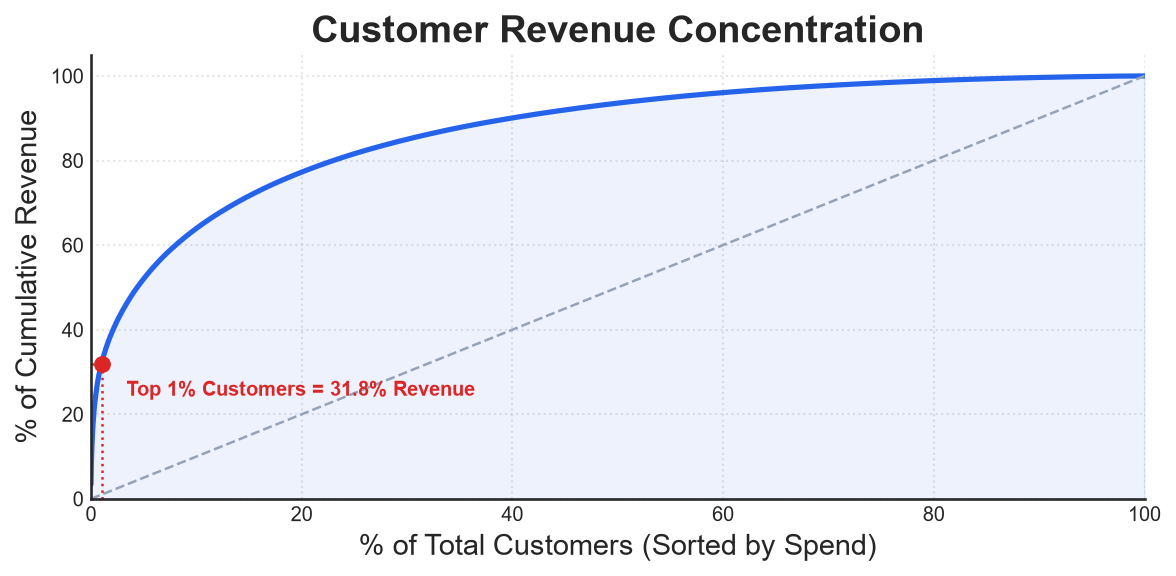

In [11]:
customer_revenue = (
    df_clean_temp
    .groupby("Customer ID")["LineTotal"]
    .sum()
    .sort_values(ascending=False)
)

cum_customers_pct = np.linspace(0, 100, len(customer_revenue))
cum_revenue_pct = (customer_revenue.cumsum() / customer_revenue.sum()) * 100

top_1_idx = max(1, int(len(customer_revenue) * 0.01))
top_1_rev_pct = (customer_revenue.iloc[:top_1_idx].sum() / customer_revenue.sum()) * 100

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

ax.plot(cum_customers_pct, cum_revenue_pct, color="#2563EB", lw=2.5)
ax.fill_between(cum_customers_pct, cum_revenue_pct, color="#2563EB", alpha=0.08)

ax.plot([0, 100], [0, 100], color="#94A3B8", linestyle="--", lw=1.2, label="Perfect Equality")

ax.scatter([1], [top_1_rev_pct], color="#DC2626", s=50, zorder=5)
ax.vlines(1, 0, top_1_rev_pct, color="#DC2626", linestyle=":", lw=1.2)
ax.hlines(top_1_rev_pct, 0, 1, color="#DC2626", linestyle=":", lw=1.2)

ax.annotate(
    f"Top 1% Customers = {top_1_rev_pct:.1f}% Revenue",
    xy=(1, top_1_rev_pct),
    xytext=(12, -15), textcoords="offset points",
    fontweight="bold", color="#DC2626", fontsize=9.5
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.set_xlabel("% of Total Customers (Sorted by Spend)")
ax.set_ylabel("% of Cumulative Revenue")
plt.title("Customer Revenue Concentration")

sns.despine(top=True, right=True)
ax.grid(axis="both", linestyle=":", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True)
ax.tick_params(length=0, labelsize=9.5)

plt.tight_layout()
print(f"Revenue generated by top 1% customers: {top_1_rev_pct:.2f}%")

**Top 1% Account Impact**: The top 1% of customers account for **31.77% of total revenue**, highlighting severe revenue concentration among wholesale or high-volume enterprise buyers

## 8. Geographic Customer Distribution

To understand the geographic composition of the customer base, we identify the **top 10 countries by unique customer count**.

This analysis helps determine where the customer base is concentrated and provides useful context for interpreting the customer segments identified later.

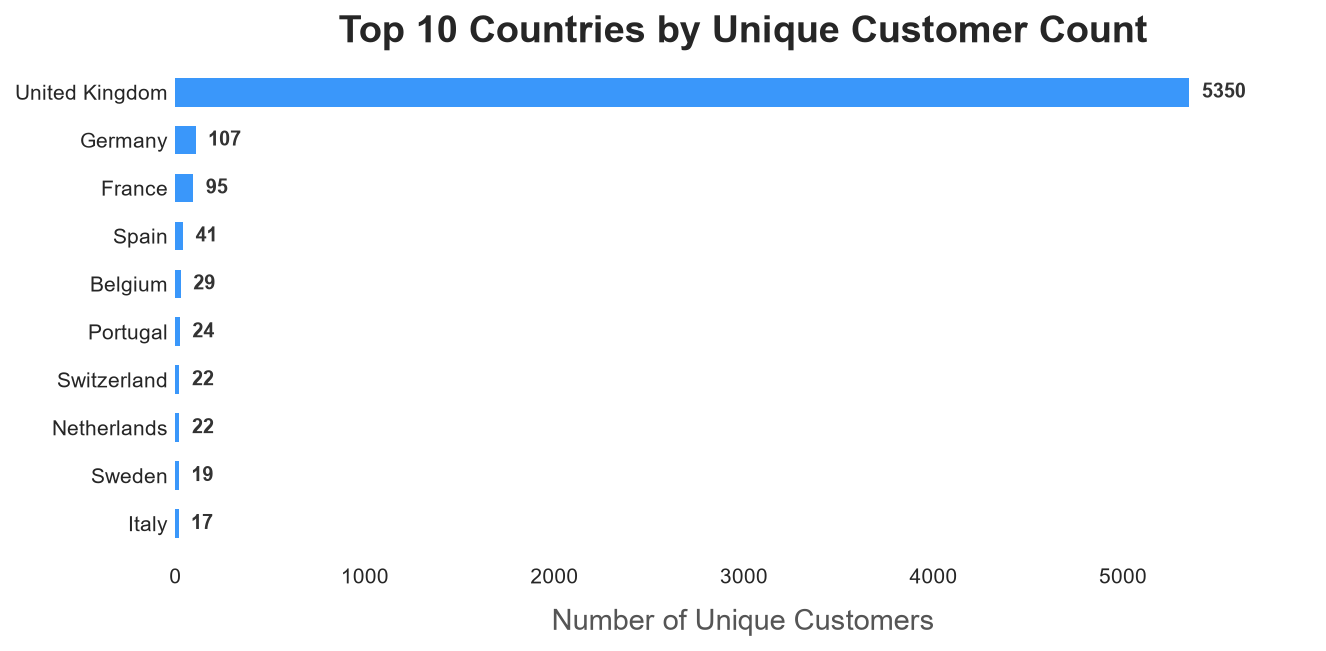

In [12]:
top_countries = (
    df_clean_temp.groupby("Country")["Customer ID"]
    .nunique()
    .nlargest(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=150)

bars = ax.barh(
    top_countries.index,
    top_countries.values,
    color="#3A97FA",
    height=0.6,
    edgecolor="none",
)

ax.bar_label(
    bars,
    fmt="%d",
    padding=6,
    fontweight="bold",
    color="#333333",
    fontsize=9.5,
)

sns.despine(top=True, right=True, left=True, bottom=True)

ax.tick_params(axis="both", which="both", length=0, labelsize=10)
ax.set_xlabel("Number of Unique Customers", color="#555555", labelpad=10)

plt.title("Top 10 Countries by Unique Customer Count")

ax.set_xlim(0, max(top_countries.values) * 1.12)
plt.tight_layout()

The customer base is highly concentrated in the **United Kingdom**, with approximately **5,350 unique purchasing customers**, compared with **107 in Germany and 95 in France**. This geographic imbalance should be considered when interpreting future customer segments, because clustering results may primarily reflect UK purchasing behavior.

## 9. Temporal Purchasing Patterns

We examine how purchase activity changes over time to identify seasonality,
long-term trends, and periods of unusually high or low commercial activity.

Two perspectives are explored:

- **Monthly revenue:** reveals broad temporal patterns and seasonal peaks.
- **Day-of-week behavior:** shows whether purchasing activity is concentrated
  on particular weekdays.

These findings provide business context but will not be directly used as
customer segmentation features unless they can be meaningfully aggregated
at the customer level.

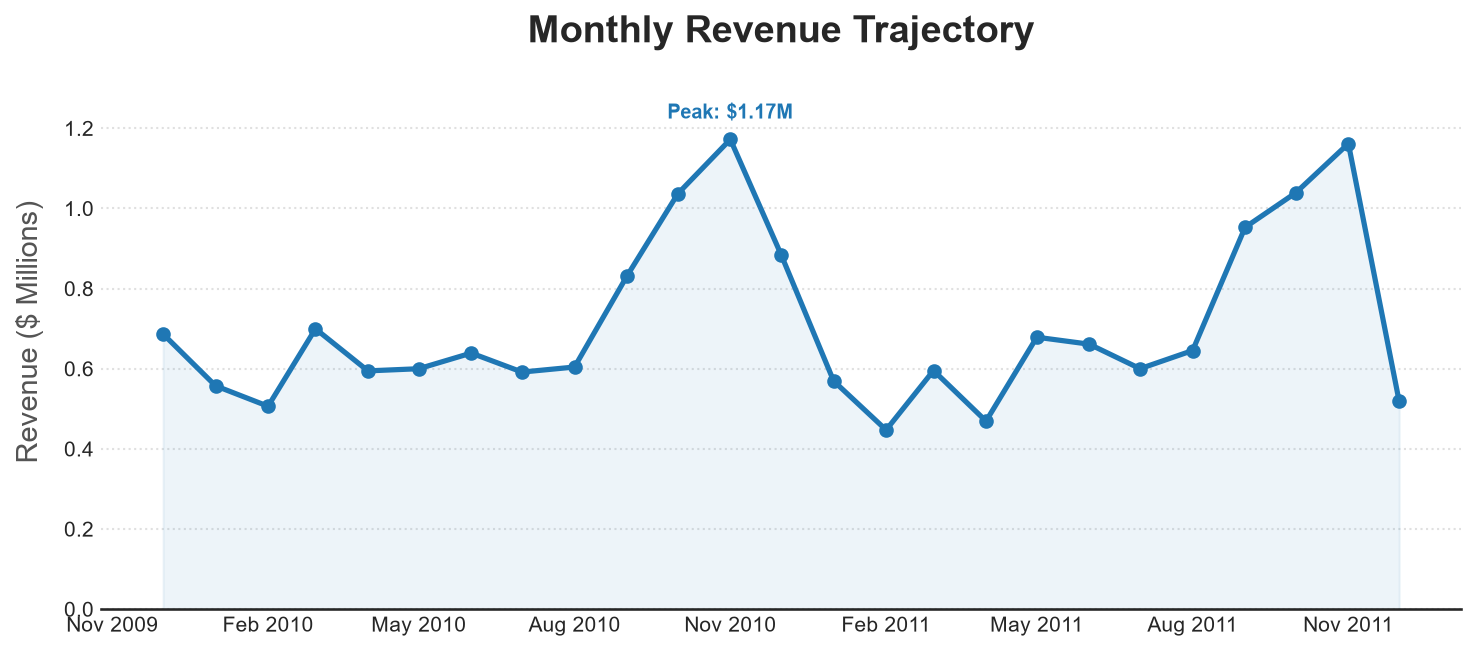

In [13]:
df_clean_temp['InvoiceDate'] = pd.to_datetime(df_clean_temp['InvoiceDate'])

monthly = (
    df_clean_temp.set_index("InvoiceDate")["LineTotal"]
    .resample("MS")
    .sum()
    .reset_index()
)
monthly["Revenue_M"] = monthly["LineTotal"] / 1e6

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)

ax.plot(monthly["InvoiceDate"], monthly["Revenue_M"], color="#1f77b4", lw=2.5, marker="o", ms=6)
ax.fill_between(monthly["InvoiceDate"], monthly["Revenue_M"], color="#1f77b4", alpha=0.08)

peak_row = monthly.loc[monthly["Revenue_M"].idxmax()]
ax.annotate(
    f"Peak: ${peak_row['Revenue_M']:.2f}M",
    xy=(peak_row["InvoiceDate"], peak_row["Revenue_M"]),
    xytext=(0, 10), textcoords="offset points", ha="center",
    fontweight="bold", color="#1f77b4", fontsize=9.5
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax.set_ylim(0, monthly["Revenue_M"].max() * 1.18)
ax.set_ylabel("Revenue ($ Millions)", color="#555555", labelpad=10)
plt.title("Monthly Revenue Trajectory")

sns.despine(top=True, right=True, left=True)
ax.grid(axis="y", linestyle=":", alpha=0.6, color="#cccccc")
ax.set_axisbelow(True)
ax.tick_params(length=0, labelsize=10)

plt.tight_layout()

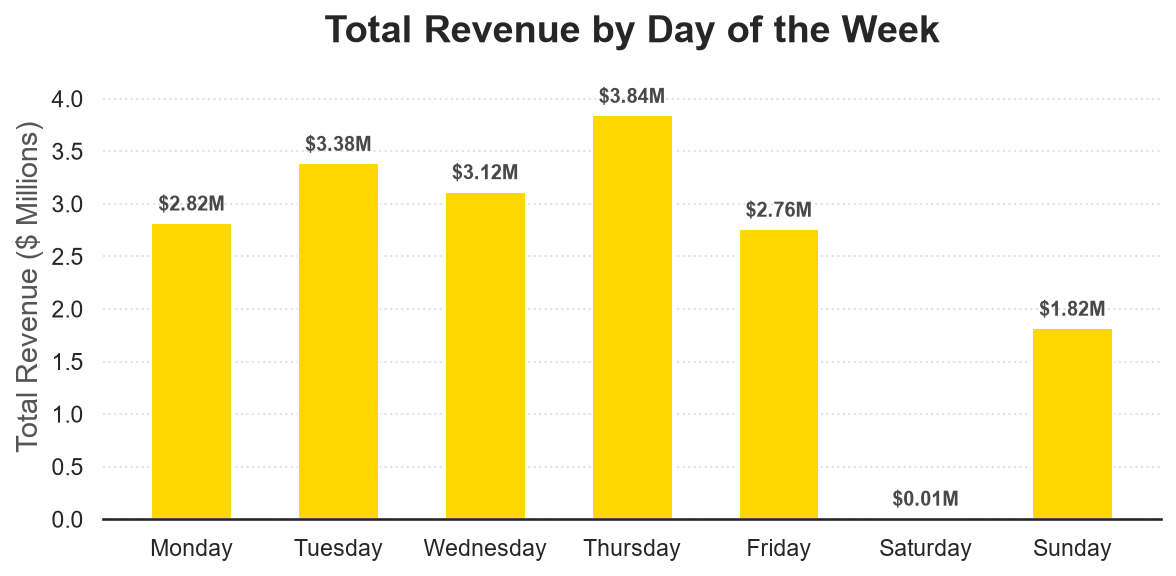

In [14]:
df_clean_temp["DayOfWeek"] = pd.to_datetime(df_clean_temp["InvoiceDate"]).dt.day_name()

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_revenue = (
    df_clean_temp.groupby("DayOfWeek")["LineTotal"]
    .sum()
    .reindex(days_order)
    / 1e6
)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
bars = ax.bar(daily_revenue.index, daily_revenue.values, color='gold', width=0.55)

labels = [f"${v:.2f}M" for v in daily_revenue.values]
ax.bar_label(bars, labels=labels, padding=4, fontweight="bold", color="#494949", fontsize=9.5)

ax.set_ylim(0, daily_revenue.max() * 1.15)
ax.set_ylabel("Total Revenue ($ Millions)", color="#555555")
plt.title("Total Revenue by Day of the Week")

sns.despine(top=True, right=True, left=True)
ax.grid(axis="y", linestyle=":", alpha=0.65, color="#d3d3d3")

plt.tight_layout()

- **Q4 Seasonality Surge:** Revenue rises sharply from September and peaks in **November**, likely driven by holiday demand and promotional activity.
- **Q1 Post-Holiday Pullback:** Revenue declines from January through April as customers adjust inventory after the holiday period.
- **Mid-Week Ordering:** **Thursday and Tuesday** generate the highest cumulative revenue, indicating stronger mid-week purchasing activity.
- **Saturday Operational Gap:** Saturday has minimal or no transactions, likely reflecting reduced weekend operations.

## 10. Production Pipeline Engineering Checklist

Based on this EDA audit, the core data pipeline must enforce the following preprocessing and engineering rules:

- **Data Ingestion & Cleaning:**
  - Strip missing `Customer ID` entries (~22.7% of rows).
  - Remove duplicate transaction logs.
  - Drop zero/negative price entries.
  
- **Feature Engineering:**
  - Separate canceled invoices (`'C'`) to compute `return_rate` and `canceled_invoices` per account before excluding them from gross revenue.
  - Compute Recency, Frequency, Monetary, Average Order Value (AOV), Purchase Velocity, etc.
  
- **Data Preprocessing & Scaling:**
  - Apply custom `Log1pTransformer` to right-skewed metrics (`Monetary`, `Frequency`, `Recency`, `AOV`, etc.).
  - Use `RobustScaler` instead of `StandardScaler` to prevent remaining bulk-purchaser outliers from overwhelming variance scaling.

- **Dimensionality Reduction:**
  - Evaluate PCA to understand variance structure, reduce correlated information where beneficial, support visualization, and determine experimentally whether clustering improves in the reduced feature space.